<a href="https://colab.research.google.com/github/Clover130/EMSC2010-W7-L1/blob/main/EMSC2010_W7_L1_NB3_u8229609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W7-L1-NB3

In this notebook we'll look at different approaches to estimating the posterior distribution of student average height.

In the first case, we'll see how the posterior can be calculated analytically. Then we'll investigate how to *sample* the posterior using *Probabilistic Programming* via the ```PyMC``` package.

First we'll import the packages we'll need, including ```PyMC``` and ```Arviz``` which is used for the analysis of Bayesian models.

We'll also import the ```stats``` module from ```scipy``` which contains a function for calculating *t*-distributions.

In [1]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Now we can input and plot the height data that we collected during Week 5.

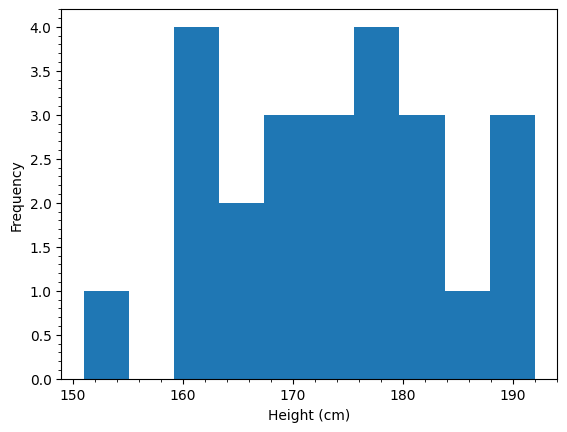

In [2]:
data = np.array([151,177,173,162,160,178,192,161,163,167,172,187,178,182,189,181,173,191,164,179,182,170,170,168]) #height data
plt.hist(data) #plot histogram of heights
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.minorticks_on()

We want to estimate mean height of the population based on the information in the sample.

One way to do this to fit a normal distribution to the sample.

Remember that normal distributions are defined by two parameters:
* $\mu$ = distribution mean
* $\sigma$ = distribution standard deviation

Therefore, we need to define priors for both $\mu$ and $\sigma$.

One approach is to use "non-informative" priors. A non-informative prior is one that lets the data dominate the posterior, contributing as little prior knowledge as possible. This usually means spreading the prior probability as flatly as possible over the parameter space to express "ignorance" about where the parameter might lie before seeing any data.

If the case of a normal distribution where the mean and variance are unknown, the non-informative prior is:

$p(\mu,\sigma) \propto \frac{1}{\sigma^2}$

With this prior, the posterior distribution for the mean is a $t$-distribution with:
* mean = $\bar{x}$
* degrees of freedom = $n$-1
* scale = $\frac{s}{\sqrt(n)}$

where $\bar{x}$ and $s$ is the mean and standard deviation of the sample, respectively.

We can write code this to find the posterior directly.


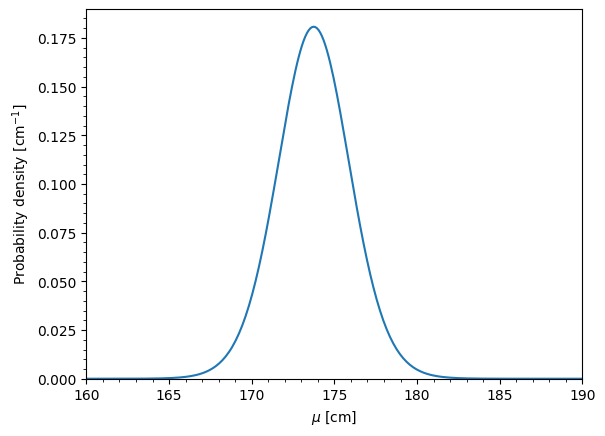

In [3]:
n = len(data) #number of data points
xbar = np.mean(data) #the mean of the sample
s = data.std(ddof=1) #the standard deviation of the sample

# Analytical posterior for the mean:
mu_grid = np.linspace(160, 190, 300) #collection of x-values for plotting
analytic_pdf = stats.t.pdf(mu_grid, df=n-1, loc=xbar, scale=s/np.sqrt(n)) #find the values of the posterior along the x-axis
plt.plot(mu_grid,analytic_pdf) #plot the posterior distribution
plt.xlabel(r"$\mu$ [cm]") #label the x-axis
plt.ylabel("Probability density [cm$^{-1}$]") #label the y-axis
plt.xlim([160,190])
plt.ylim(bottom=0)
plt.minorticks_on()

This is a simple example, however for more complex problems, the mathematics to find an analytical (i.e., an equation) representation of the posterior distribution is often intractable.

## Probabilistic programming
Lets you describe a statistical model in code and then the software automatically handles the computation for you. You specify two things:

* Priors — your beliefs about parameters before seeing data.
* Likelihood — how the data are generated given those parameters.

And the probabilistic programming system (like PyMC) takes care of computing the posterior (typically using Markov chain Monte Carlo).

The power of this approach is that models which would be analytically intractable can still be fitted just by describing their structure. This lets you focus on model building rather than computational statistics.

### Using PyMC to find the posterior distribution

We'll create a ```PyMC``` model to:

1.   Define priors for the normal distribution using the same non-informative approach we used above.
2.   Define the likelihood
3.   Sample the posterior


Output()

<Axes: title={'center': 'mu'}>

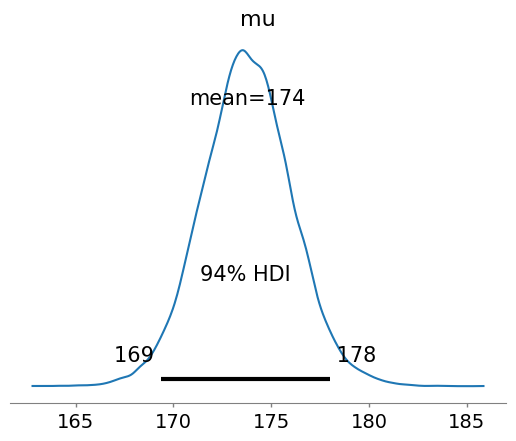

In [4]:
with pm.Model() as jeffreys_model:

    # Noninformative prior: p(μ, σ) ∝ 1/σ²
    # Equivalent to a flat prior on μ and log(σ)
    mu = pm.Flat("mu")                          # flat prior on μ (always the same value)
    log_sigma = pm.Flat("log_sigma")            # flat prior on log(σ)
    sigma = pm.Deterministic("sigma", pm.math.exp(log_sigma)) #represents the non-informative prior

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data)

    # Obtain 20,000 samples from the posterior
    trace = pm.sample(20000, tune=2000, return_inferencedata=True)

az.plot_posterior(trace, var_names=["mu"]) #plot the posterior distribution for the mean

We can also compare the analytical posterior and the one sampled by ```PyMC```.

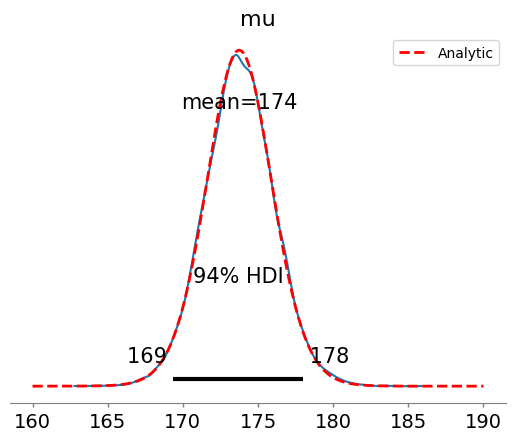

In [5]:
fig, ax = plt.subplots()
az.plot_posterior(trace, var_names=["mu"], ax=ax)
ax.plot(mu_grid, analytic_pdf, "r--", lw=2, label="Analytic")
ax.legend()

### Informative priors
The example above assumed that we have no prior information about the distribution. However when working with heights we do have useful prior information that can be incorperated into the model (before we look at our data).

For example we could consider it reasonable that our knowledge of mean average high can be described by a normal distribution with mean 170 cm and standard deviation of 10 cm.

We also need to consider what the standard deviation of the height distribution. Standard deviations must be positive, so we could use the positive side of a normal distribution with a mean of zero and standard deviation of 20 cm.

Output()

<Axes: title={'center': 'mu'}>

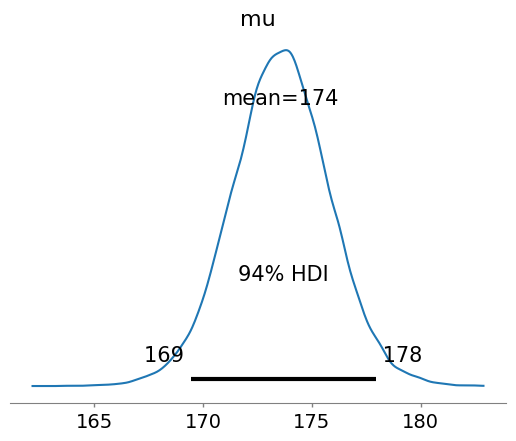

In [6]:
with pm.Model() as informative_model:

    # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
    mu = pm.Normal("mu", mu=170, sigma=10)

    # Prior for std of heights — HalfNormal with a standard deviation of 20.
    sigma = pm.HalfNormal("sigma", sigma=20)

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data)

    # Obtain 20,000 samples from the posterior
    trace = pm.sample(20000, tune=2000, return_inferencedata=True)

#plot the posterior distribution for the mean
az.plot_posterior(trace, var_names=["mu"])

I can also extract the samples of the posterior distribution for plotting, furthur analysis, etc.

95% HDI = 169.4 to 178.0 cm


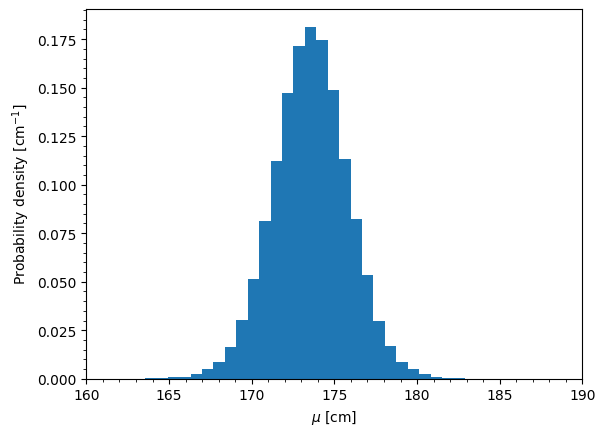

In [7]:
# Extract the posterior samples as a numpy array
mu_samples = trace.posterior["mu"].values.flatten()
plt.hist(mu_samples,bins=30,density=True);
plt.xlabel(r"$\mu$ [cm]") #label the x-axis
plt.ylabel("Probability density [cm$^{-1}$]") #label the y-axis
plt.xlim([160,190])
plt.ylim(bottom=0)
plt.minorticks_on()
hdi95 = az.hdi(mu_samples) #find the 95% hdi
print('95% HDI = {:.1f} to {:.1f} cm'.format(hdi95[0],hdi95[1]))